# Test transformer and training implementation
This notebook can be uploaded to Google Colab and used to test, debug, and tune model architecture, params, and training logic for both standard parameterization and μP parameterization on the tiny model before running the full Python script on a GPU.

Note: Must upload train.bin and val.bin to your files on Colab.

In [4]:
import inspect
from contextlib import nullcontext
import dataclasses
from dataclasses import dataclass
import time

import math
import numpy as np

import torch
import torch.nn as nn
from torch.nn import functional as F

In [5]:
!nvidia-smi

Fri May  1 02:21:57 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   38C    P8             12W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Model Architecture

In [2]:
class LayerNorm(nn.Module):
    """
    LayerNorm but with an optional bias.
    Adapted from nanoGPT with minimal modifications.
    """

    def __init__(self, ndim, bias):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(ndim))
        self.bias = nn.Parameter(torch.zeros(ndim)) if bias else None

    def forward(self, input):
        return F.layer_norm(input, self.weight.shape, self.weight, self.bias, 1e-5)

In [3]:
class CausalSelfAttention(nn.Module):
    """
    Causal self-attention layer with multiple heads.
    Adapted from nanoGPT with minimal modifications.
    """

    def __init__(self, config):
        super().__init__()

        if config.d_model % config.n_head != 0:
            raise ValueError(f"d_model ({config.d_model}) must be divisible by n_head ({config.n_head})")

        # Key, query, value projections for all heads, but in a batch
        self.c_attn = nn.Linear(config.d_model, 3 * config.d_model, bias=config.bias)

        # Output projection
        self.c_proj = nn.Linear(config.d_model, config.d_model, bias=config.bias)

        # Regularization
        self.attn_dropout = nn.Dropout(config.dropout)
        self.resid_dropout = nn.Dropout(config.dropout)
        self.n_head = config.n_head
        self.d_model = config.d_model
        self.dropout = config.dropout

        # Flash attention requires PyTorch >= 2.0.
        # If not available, will use the manual (slower) implementation of attention.
        self.flash = hasattr(F, 'scaled_dot_product_attention')
        if not self.flash:
            print("Warning: Using slow attention. Flash Attention requires PyTorch >= 2.0")
            # Causal mask to ensure that attention is only applied to the left in the input sequence
            self.register_buffer("bias", torch.tril(torch.ones(config.block_size, config.block_size))
                                        .view(1, 1, config.block_size, config.block_size))

    def forward(self, x):
        B, T, C = x.size() # batch size, sequence length, embedding dimensionality (d_model)

        # Calculate query, key, values for all heads in batch and move head forward to be the batch dim
        q, k, v  = self.c_attn(x).split(self.d_model, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)

        # Causal self-attention - Self-attend: (B, nh, T, hs) x (B, nh, hs, T) -> (B, nh, T, T)
        if self.flash:
            # Efficient attention using Flash Attention CUDA kernels
            y = F.scaled_dot_product_attention(
                q, k, v, attn_mask=None, dropout_p=self.dropout if self.training else 0, is_causal=True
            )
        else:
            # Manual implementation of attention
            att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
            att = att.masked_fill(self.bias[:,:,:T,:T] == 0, float('-inf'))
            att = F.softmax(att, dim=-1)
            att = self.attn_dropout(att)
            y = att @ v # (B, nh, T, T) x (B, nh, T, hs) -> (B, nh, T, hs)

        y = y.transpose(1, 2).contiguous().view(B, T, C) # re-assemble all head outputs side by side

        # Output projection
        y = self.resid_dropout(self.c_proj(y))
        return y

In [4]:
class MLP(nn.Module):
    """
    MLP layer - simple linear layer followed by a non-linearity.
    Adapted from nanoGPT with minimal modifications.
    """

    def __init__(self, config):
        super().__init__()
        # nanoGPT uses 4*d_model for the hidden dimensions of the MLP - here we use d_ff
        self.c_fc    = nn.Linear(config.d_model, config.d_ff, bias=config.bias)
        self.gelu    = nn.GELU()
        self.c_proj  = nn.Linear(config.d_ff, config.d_model, bias=config.bias)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x):
        x = self.c_fc(x)
        x = self.gelu(x)
        x = self.c_proj(x)
        x = self.dropout(x)
        return x

In [5]:
class Block(nn.Module):
    """
    Transformer block - attention followed by a MLP, with skip connections and layer norm.
    Adapted from nanoGPT with minimal modifications.
    """

    def __init__(self, config):
        super().__init__()
        self.ln_1 = LayerNorm(config.d_model, bias=config.bias)
        self.attn = CausalSelfAttention(config)
        self.ln_2 = LayerNorm(config.d_model, bias=config.bias)
        self.mlp = MLP(config)

    def forward(self, x):
        x = x + self.attn(self.ln_1(x)) # skip connection around attention
        x = x + self.mlp(self.ln_2(x))  # skip connection around MLP
        return x

In [6]:
class Transformer(nn.Module):
    """
    The full transformer language model.
    Adapted from nanoGPT with minimal modifications.
    """

    def __init__(self, config):
        super().__init__()
        if config.vocab_size is None or config.block_size is None:
            raise ValueError("vocab_size and block_size must be specified")

        self.config = config

        self.transformer = nn.ModuleDict(dict(
            token_embedding = nn.Embedding(config.vocab_size, config.d_model),
            pos_embedding = nn.Embedding(config.block_size, config.d_model),
            dropout = nn.Dropout(config.dropout),
            h = nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
            ln_f = LayerNorm(config.d_model, bias=config.bias),
        ))
        self.lm_head = nn.Linear(config.d_model, config.vocab_size, bias=False)
        self.transformer.token_embedding.weight = self.lm_head.weight # https://paperswithcode.com/method/weight-tying

        # Initialize all weights
        self.apply(self._init_weights)
        # Apply special scaled init to the residual projections, per GPT-2 paper
        for pn, p in self.named_parameters():
            if pn.endswith('c_proj.weight'):
                torch.nn.init.normal_(p, mean=0.0, std=0.02/math.sqrt(2 * config.n_layer))

        # Report number of parameters
        print(f"Number of model parameters: {self._get_num_params()/1e6:.2f}M")

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def _get_num_params(self, non_embedding=True):
        """
        Return the number of parameters in the model.
        For non-embedding count (default), the position embeddings get subtracted.
        The token embeddings would too, except due to the parameter sharing these
        params are actually used as weights in the final layer, so we include them.
        """
        n_params = sum(p.numel() for p in self.parameters())
        if non_embedding:
            n_params -= self.transformer.pos_embedding.weight.numel()
        return n_params

    def forward(self, idx, targets=None):
        device = idx.device
        b, t = idx.size()
        if t > self.config.block_size:
            raise ValueError(
                f"Cannot forward sequence of length {t}, block size is only {self.config.block_size}"
            )
        pos = torch.arange(0, t, dtype=torch.long, device=device) # shape (t)

        tok_emb = self.transformer.token_embedding(idx) # token embeddings of shape (b, t, d_model)
        pos_emb = self.transformer.pos_embedding(pos) # position embeddings of shape (t, d_model)
        x = self.transformer.dropout(tok_emb + pos_emb)

        for block in self.transformer.h:
            x = block(x)
        x = self.transformer.ln_f(x)

        if targets is not None:
            # If we are given some desired targets also calculate the loss
            logits = self.lm_head(x)
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1), ignore_index=-1)
        else:
            # Inference-time mini-optimization: only forward the lm_head on the very last position
            logits = self.lm_head(x[:, [-1], :]) # note: using list [-1] to preserve the time dim
            loss = None

        return logits, loss

## Configure Optimizer

In [8]:
def _build_adamw_optimizer(model: torch.nn.Module, config) -> torch.optim.AdamW:
    """
    Standard AdamW optimizer.
    Adapted from nanoGPT's optimizer configuration:
    https://github.com/karpathy/nanoGPT/blob/master/model.py#L263
    """
    # Start with all of the candidate parameters
    param_dict = {pn: p for pn, p in model.named_parameters()}

    # Filter out those that do not require grad
    param_dict = {pn: p for pn, p in param_dict.items() if p.requires_grad}

    # Create optim groups. Any parameters that is 2D will be weight decayed, otherwise no.
    # i.e. all weight tensors in matmuls + embeddings decay, all biases and layernorms don't.
    decay_params = [p for n, p in param_dict.items() if p.dim() >= 2]
    nodecay_params = [p for n, p in param_dict.items() if p.dim() < 2]
    optim_groups = [
        {"params": decay_params, "weight_decay": config.weight_decay},
        {"params": nodecay_params, "weight_decay": 0.0},
    ]

    n_decay = sum(p.numel() for p in decay_params)
    n_nodecay = sum(p.numel() for p in nodecay_params)
    print(f"Number decayed parameter tensors: {len(decay_params)}, with {n_decay:,} parameters")
    print(f"Number non-decayed parameter tensors: {len(nodecay_params)}, with {n_nodecay:,} parameters")

    # Create AdamW optimizer and use the fused version if it is available
    fused_available = "fused" in inspect.signature(torch.optim.AdamW).parameters
    use_fused = fused_available and config.device == "cuda"
    extra_args = dict(fused=True) if use_fused else dict()
    if use_fused:
        print("Using fused AdamW kernel.")

    return torch.optim.AdamW(
        optim_groups,
        lr=config.learning_rate,
        betas=config.betas,
        **extra_args,
    )

In [9]:
def build_optimizer(model: torch.nn.Module, config) -> torch.optim.Optimizer:
  return _build_adamw_optimizer(model, config)

## Training Loop

In [10]:
# Set training and validation files
TRAIN = "train.bin"
VAL = "val.bin"

In [11]:
def _get_batch(
    path: str,
    batch_size: int,
    block_size: int,
    device: str,
) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Sample a random batch from a tokenized .bin file.

    The memmap is recreated on every call to avoid a memory leak as discussed in demo-rnns.ipynb:
    https://colab.research.google.com/drive/1R1T7PlKjuUISzgulTQ8wX4RwUBB4crDo?usp=sharing
    """
    data = np.memmap(path, dtype=np.uint16, mode="r")
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([torch.from_numpy(data[i : i + block_size].astype(np.int64)) for i in ix])
    y = torch.stack([torch.from_numpy(data[i + 1 : i + block_size + 1].astype(np.int64)) for i in ix])

    if "cuda" in str(device):
        x = x.pin_memory().to(device, non_blocking=True)
        y = y.pin_memory().to(device, non_blocking=True)
    else:
        x, y = x.to(device), y.to(device)

    return x, y

In [12]:
def _get_lr(step: int, config) -> float:
    """
    Cosine learning rate schedule with linear warmup.
    Adapted from nanoGPT's implementation of the learning rate schedule.
    """
    lr = config.learning_rate
    min_lr = config.min_lr
    warmup_iters = config.warmup_steps
    lr_decay_iters = config.total_steps

    # 1. Linear warmup for the first `warmup_iters` steps
    if step < warmup_iters:
        return lr * (step + 1) / (warmup_iters + 1)

    # 2. If step > lr_decay_iters, return min learning rate
    if step > lr_decay_iters:
        return min_lr

    # 3. In between, use cosine decay down to min learning rate
    decay_ratio = (step - warmup_iters) / (lr_decay_iters - warmup_iters)
    assert 0 <= decay_ratio <= 1
    coeff = 0.5 * (1.0 + math.cos(math.pi * decay_ratio))  # coeff ranges 0..1
    return min_lr + coeff * (lr - min_lr)

In [13]:
@torch.no_grad()
def estimate_loss(model: Transformer, config, ctx) -> dict[str, float]:
    out = {}
    model.eval()
    for split, path in [("train", TRAIN), ("val", VAL)]:
        losses = torch.zeros(config.eval_iters)
        for k in range(config.eval_iters):
            X, Y = _get_batch(path, config.micro_batch_size, config.block_size, config.device)
            with ctx:
                _, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean().item()
    model.train()
    return out

In [34]:
def train(config) -> None:
    """
    Training loop.
    Adapted from nanoGPT's training loop.
    """
    torch.manual_seed(config.seed)
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    ptdtype = torch.bfloat16
    ctx = nullcontext() if config.device == 'cpu' else torch.amp.autocast(device_type=config.device, dtype=ptdtype)

    # Initialize model, optimizer, and metrics logger
    model = Transformer(config).to(config.device)
    model = torch.compile(model)
    optimizer = build_optimizer(model, config)

    batch_size = config.batch_size_tokens // config.block_size  # full effective batch size
    grad_accum_steps = max(1, batch_size // config.micro_batch_size)  # number of steps to accumulate gradients before an optimizer step
    config.micro_batch_size = batch_size // grad_accum_steps

    tokens_per_step = config.micro_batch_size * config.block_size * grad_accum_steps  # number of tokens processed per optimizer step
    n_train_tokens = len(np.memmap(TRAIN, dtype=np.uint16, mode="r"))
    total_steps = n_train_tokens // tokens_per_step  # total iterations for 1 epoch through the training data
    config.total_steps = total_steps

    print(
        f"Training: steps={total_steps}  micro_batch={config.micro_batch_size}  grad_accum={grad_accum_steps}  tokens/step={tokens_per_step}  n_train_tokens={n_train_tokens}"
    )

    model.train()
    accum_loss = 0.0
    for step in range(total_steps):
        # Get and set the learning rate for this step
        lr = _get_lr(step, config)
        for group in optimizer.param_groups:
            group["lr"] = lr

        # Forward backward update, with gradient accumulation to simulate larger batch size
        for _ in range(grad_accum_steps):
            x, y = _get_batch(TRAIN, config.micro_batch_size, config.block_size, config.device)
            # Compute loss and backprop
            with ctx:
                _, loss = model(x, y)
            loss = loss / grad_accum_steps   # scale the loss to account for gradient accumulation
            loss.backward()
            accum_loss += loss.item()

        # Gradient clipping
        if config.grad_clip > 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), config.grad_clip)

        optimizer.step()
        optimizer.zero_grad(set_to_none=True)

        train_loss = accum_loss
        accum_loss = 0.0

        if step % config.log_interval == 0:
            print(f"step {step}/{total_steps}  loss={train_loss:.4f}  lr={lr:.2e}")

        if step > 0 and step % config.eval_interval == 0:
            val_loss = estimate_loss(model, config, ctx)
            print(f"step {step}  val_loss={val_loss['val']:.4f}")

    # Final evaluation for the scaling plot
    val_loss = estimate_loss(model, config, ctx)
    print(f"Training complete. Final val_loss={val_loss['val']:.4f}")

    return val_loss

### Define the Model and Training Hyperparameters

In [37]:
@dataclass
class TrainConfig:
    n_layer: int = 4
    n_head: int = 4
    d_model: int = 128
    d_ff: int = 512
    block_size: int = 1024
    vocab_size: int = 4096
    bias: bool = False
    dropout: float = 0.0

    # Training
    learning_rate: float = 3e-4
    batch_size_tokens: int = 524288
    micro_batch_size: int = 256
    min_lr: float = 3e-5
    warmup_steps: int = 20
    optimizer: str = "adamw"
    weight_decay: float = 0.1
    grad_clip: float = 1.0
    betas: tuple = (0.9, 0.95)
    seed: int = 1337

    # Logging / evaluation
    log_interval: int = 10
    eval_interval: int = 500
    eval_iters: int = 50

    # Device
    device: str = "cuda"

    # Set during training
    total_steps: int = 0

### Train the model

In [38]:
config = TrainConfig()
train(config)

Number of model parameters: 1.31M
Number decayed parameter tensors: 18, with 1,441,792 parameters
Number non-decayed parameter tensors: 9, with 1,152 parameters
Using fused AdamW kernel.
Training: steps=208  micro_batch=256  grad_accum=2  tokens/step=524288  n_train_tokens=109293121
step 0/208  loss=8.3190  lr=1.43e-05
step 10/208  loss=7.4476  lr=1.57e-04
step 20/208  loss=6.9080  lr=3.00e-04
step 30/208  loss=6.2033  lr=2.98e-04
step 40/208  loss=5.5282  lr=2.93e-04
step 50/208  loss=4.8994  lr=2.83e-04
step 60/208  loss=4.3442  lr=2.71e-04
step 70/208  loss=3.8920  lr=2.56e-04
step 80/208  loss=3.5470  lr=2.38e-04
step 90/208  loss=3.2762  lr=2.18e-04
step 100/208  loss=3.0794  lr=1.96e-04
step 110/208  loss=2.9157  lr=1.74e-04
step 120/208  loss=2.8029  lr=1.51e-04
step 130/208  loss=2.7058  lr=1.29e-04
step 140/208  loss=2.6404  lr=1.08e-04
step 150/208  loss=2.5923  lr=8.86e-05
step 160/208  loss=2.5551  lr=7.11e-05
step 170/208  loss=2.5272  lr=5.63e-05
step 180/208  loss=2.4911

{'train': 2.4496774673461914, 'val': 2.4431264400482178}

# μP Scaling
Now let's implement this using μP with the `mup` package.

In [6]:
import mup
import mup.init
from mup import MuAdamW, set_base_shapes

## Model Architecture
Modified for μP implementation.

In [7]:
class LayerNorm(nn.Module):
    """
    LayerNorm but with an optional bias.
    Adapted from nanoGPT with minimal modifications.
    """

    def __init__(self, ndim, bias):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(ndim))
        self.bias = nn.Parameter(torch.zeros(ndim)) if bias else None

    def forward(self, input):
        return F.layer_norm(input, self.weight.shape, self.weight, self.bias, 1e-5)

In [26]:
class CausalSelfAttention(nn.Module):
    """Causal self-attention layer with multiple heads. Adapted from nanoGPT."""

    def __init__(self, config):
        super().__init__()

        if config.d_model % config.n_head != 0:
            raise ValueError(f"d_model ({config.d_model}) must be divisible by n_head ({config.n_head})")

        # Key, query, value projections for all heads, but in a batch
        self.c_attn = (mup.Linear if config.use_mup else nn.Linear)(config.d_model, 3 * config.d_model, bias=config.bias)

        # Output projection
        self.c_proj = (mup.Linear if config.use_mup else nn.Linear)(config.d_model, config.d_model, bias=config.bias)

        # Regularization
        self.attn_dropout = nn.Dropout(config.dropout)
        self.resid_dropout = nn.Dropout(config.dropout)
        self.n_head = config.n_head
        self.d_model = config.d_model
        self.dropout = config.dropout
        self.use_mup = config.use_mup

        # Flash attention requires PyTorch >= 2.0.
        # If not available, will use the manual (slower) implementation of attention.
        self.flash = hasattr(F, 'scaled_dot_product_attention')
        if not self.flash:
            print("Warning: Using slow attention. Flash Attention requires PyTorch >= 2.0")
            # Causal mask to ensure that attention is only applied to the left in the input sequence
            self.register_buffer("bias", torch.tril(torch.ones(config.block_size, config.block_size))
                                        .view(1, 1, config.block_size, config.block_size))

    def forward(self, x):
        B, T, C = x.size() # batch size, sequence length, embedding dimensionality (d_model)

        # Calculate query, key, values for all heads in batch and move head forward to be the batch dim
        q, k, v  = self.c_attn(x).split(self.d_model, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)

        d_head = C // self.n_head   # dimension per attention head
        # Use alternative attention scaling for µP per https://github.com/microsoft/mup#basic-usage
        attn_scale = (1.0 / d_head) if self.use_mup else (1.0 / math.sqrt(d_head))

        # Causal self-attention - Self-attend: (B, nh, T, hs) x (B, nh, hs, T) -> (B, nh, T, T)
        if self.flash:
            # Efficient attention using Flash Attention CUDA kernels
            y = F.scaled_dot_product_attention(
                q, k, v, attn_mask=None, dropout_p=self.dropout if self.training else 0, is_causal=True,
                scale=attn_scale,
            )
        else:
            # Manual implementation of attention
            att = (q @ k.transpose(-2, -1)) * attn_scale
            att = att.masked_fill(self.bias[:,:,:T,:T] == 0, float('-inf'))
            att = F.softmax(att, dim=-1)
            att = self.attn_dropout(att)
            y = att @ v # (B, nh, T, T) x (B, nh, T, hs) -> (B, nh, T, hs)

        y = y.transpose(1, 2).contiguous().view(B, T, C) # re-assemble all head outputs side by side

        # Output projection
        y = self.resid_dropout(self.c_proj(y))
        return y

In [27]:
class MLP(nn.Module):
    """MLP layer. Adapted from nanoGPT."""

    def __init__(self, config):
        super().__init__()
        # nanoGPT uses 4*d_model for the hidden dimensions of the MLP - here we use d_ff
        self.c_fc    = (mup.Linear if config.use_mup else nn.Linear)(config.d_model, config.d_ff, bias=config.bias)
        self.gelu    = nn.GELU()
        self.c_proj  = (mup.Linear if config.use_mup else nn.Linear)(config.d_ff, config.d_model, bias=config.bias)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x):
        x = self.c_fc(x)
        x = self.gelu(x)
        x = self.c_proj(x)
        x = self.dropout(x)
        return x

In [28]:
class Block(nn.Module):
    """
    Transformer block - attention followed by a MLP, with skip connections and layer norm.
    Adapted from nanoGPT with minimal modifications.
    """

    def __init__(self, config):
        super().__init__()
        self.ln_1 = LayerNorm(config.d_model, bias=config.bias)
        self.attn = CausalSelfAttention(config)
        self.ln_2 = LayerNorm(config.d_model, bias=config.bias)
        self.mlp = MLP(config)

    def forward(self, x):
        x = x + self.attn(self.ln_1(x)) # skip connection around attention
        x = x + self.mlp(self.ln_2(x))  # skip connection around MLP
        return x

In [40]:
class Transformer(nn.Module):
    """
    The full transformer language model. Adapted from nanoGPT.
    """

    def __init__(self, config):
        super().__init__()
        if config.vocab_size is None or config.block_size is None:
            raise ValueError("vocab_size and block_size must be specified")

        self.config = config
        self.use_mup = config.use_mup

        self.transformer = nn.ModuleDict(dict(
            token_embedding = nn.Embedding(config.vocab_size, config.d_model),
            pos_embedding = nn.Embedding(config.block_size, config.d_model),
            dropout = nn.Dropout(config.dropout),
            h = nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
            ln_f = LayerNorm(config.d_model, bias=config.bias),
        ))

        if config.use_mup:
            # Replace output layer with MuSharedReadout (which also uses weight tying) for µP
            self.lm_head = mup.MuSharedReadout(self.transformer.token_embedding.weight, bias=False)
        else:
            self.lm_head = nn.Linear(config.d_model, config.vocab_size, bias=False)
            # Weight tying (https://paperswithcode.com/method/weight-tying)
            self.transformer.token_embedding.weight = self.lm_head.weight

        # Initialize all weights
        self.apply(self._init_weights)

        # Apply special scaled init to the residual projections, per GPT-2 paper
        for pn, p in self.named_parameters():
            if pn.endswith('c_proj.weight'):
                torch.nn.init.normal_(p, mean=0.0, std=0.02/math.sqrt(2 * config.n_layer))

        print(f"Number of model parameters: {self._get_num_params()/1e6:.2f}M")

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def reinit_weights_mup(self) -> None:
        """
        Replace init weights with mup.init after base shapes are set
        per https://github.com/microsoft/mup#basic-usage
        """
        for module in self.modules():
            if isinstance(module, nn.Linear):
                mup.init.normal_(module.weight, mean=0.0, std=0.02)
                if module.bias is not None:
                    torch.nn.init.zeros_(module.bias)

        # Re-apply the scaled init to the residual projections as we did in __init__ but with mup.init
        for pn, p in self.named_parameters():
            if pn.endswith('c_proj.weight'):
                mup.init.normal_(p, mean=0.0, std=0.02 / math.sqrt(2 * self.config.n_layer))

        # Initialize the query matrix to 0 for µP
        self._zero_init_queries()

    def _zero_init_queries(self) -> None:
        """
        Zero-initialize the query matrix per
        https://github.com/microsoft/mup#making-your-own-coord-check-plots.
        """
        for block in self.transformer.h:
            with torch.no_grad():
                block.attn.c_attn.weight[:self.config.d_model, :].zero_()

    def _get_num_params(self, non_embedding=True):
        """
        Return the number of parameters in the model.
        For non-embedding count (default), the position embeddings get subtracted.
        The token embeddings would too, except due to the parameter sharing these
        params are actually used as weights in the final layer, so we include them.
        """
        n_params = sum(p.numel() for p in self.parameters())
        if non_embedding:
            n_params -= self.transformer.pos_embedding.weight.numel()
        return n_params

    def forward(self, idx, targets=None):
        device = idx.device
        b, t = idx.size()
        if t > self.config.block_size:
            raise ValueError(
                f"Cannot forward sequence of length {t}, block size is only {self.config.block_size}"
            )
        pos = torch.arange(0, t, dtype=torch.long, device=device) # shape (t)

        tok_emb = self.transformer.token_embedding(idx) # token embeddings of shape (b, t, d_model)
        pos_emb = self.transformer.pos_embedding(pos) # position embeddings of shape (t, d_model)
        x = self.transformer.dropout(tok_emb + pos_emb)

        for block in self.transformer.h:
            x = block(x)
        x = self.transformer.ln_f(x)

        if targets is not None:
            # If we are given some desired targets also calculate the loss
            logits = self.lm_head(x)
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1), ignore_index=-1)
        else:
            # Inference-time mini-optimization: only forward the lm_head on the very last position
            logits = self.lm_head(x[:, [-1], :]) # note: using list [-1] to preserve the time dim
            loss = None

        return logits, loss

## Configure Optimizer
MuAdamW instead of standard AdamW.

In [30]:
def _build_mup_optimizer(model: torch.nn.Module, config) -> torch.optim.Optimizer:
    """
    Optimizer using MuAdamW.
    """
    param_dict = {n: p for n, p in model.named_parameters() if p.requires_grad}

    decay_params = [p for n, p in param_dict.items() if p.dim() >= 2]
    nodecay_params = [p for n, p in param_dict.items() if p.dim() < 2]

    optim_groups = [
        {"params": decay_params, "weight_decay": config.weight_decay},
        {"params": nodecay_params, "weight_decay": 0.0},
    ]

    n_decay = sum(p.numel() for p in decay_params)
    n_nodecay = sum(p.numel() for p in nodecay_params)
    print(f"Number decayed parameter tensors (µP): {len(decay_params)}, with {n_decay:,} parameters")
    print(f"Number non-decayed parameter tensors (µP): {len(nodecay_params)}, with {n_nodecay:,} parameters")

    return MuAdamW(
        optim_groups,
        lr=config.learning_rate,
        betas=config.betas,
    )

In [31]:
def build_optimizer(model: torch.nn.Module, config) -> torch.optim.Optimizer:
    return _build_mup_optimizer(model, config)

## Training Loop

In [32]:
# Set training and validation files
TRAIN = "train.bin"
VAL = "val.bin"

In [33]:
def _get_batch(
    path: str,
    batch_size: int,
    block_size: int,
    device: str,
) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Sample a random batch from a tokenized .bin file.

    The memmap is recreated on every call to avoid a memory leak as discussed in demo-rnns.ipynb:
    https://colab.research.google.com/drive/1R1T7PlKjuUISzgulTQ8wX4RwUBB4crDo?usp=sharing
    """
    data = np.memmap(path, dtype=np.uint16, mode="r")
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([torch.from_numpy(data[i : i + block_size].astype(np.int64)) for i in ix])
    y = torch.stack([torch.from_numpy(data[i + 1 : i + block_size + 1].astype(np.int64)) for i in ix])

    if "cuda" in str(device):
        x = x.pin_memory().to(device, non_blocking=True)
        y = y.pin_memory().to(device, non_blocking=True)
    else:
        x, y = x.to(device), y.to(device)

    return x, y

In [34]:
def _get_lr(step: int, config) -> float:
    """
    Cosine learning rate schedule with linear warmup.
    Adapted from nanoGPT's implementation of the learning rate schedule.
    """
    lr = config.learning_rate
    min_lr = config.min_lr
    warmup_iters = config.warmup_steps
    lr_decay_iters = config.total_steps

    # 1. Linear warmup for the first `warmup_iters` steps
    if step < warmup_iters:
        return lr * (step + 1) / (warmup_iters + 1)

    # 2. If step > lr_decay_iters, return min learning rate
    if step > lr_decay_iters:
        return min_lr

    # 3. In between, use cosine decay down to min learning rate
    decay_ratio = (step - warmup_iters) / (lr_decay_iters - warmup_iters)
    assert 0 <= decay_ratio <= 1
    coeff = 0.5 * (1.0 + math.cos(math.pi * decay_ratio))  # coeff ranges 0..1
    return min_lr + coeff * (lr - min_lr)

In [35]:
@torch.no_grad()
def _estimate_loss(model: Transformer, config, ctx) -> dict[str, float]:
    """Estimate the loss on training and validation sets."""
    out = {}
    model.eval()
    for path, split in [(TRAIN, "train"), (VAL, "val")]:
        losses = torch.zeros(config.eval_iters)
        for k in range(config.eval_iters):
            X, Y = _get_batch(path, config.micro_batch_size, config.block_size, config.device)
            with ctx:
                _, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean().item()
    model.train()
    return out

In [49]:
def _set_base_shapes_mup(model: Transformer, config: TrainConfig, d_model_base: int) -> None:
    """Set base shapes for µP training."""

    def _mup_config(base: TrainConfig, d_model: int) -> TrainConfig:
        """Builds a new TrainConfig for µP shape construction."""
        # Preserve the ratio between d_ff and d_model when changing d_model
        ff_model_ratio = base.d_ff // base.d_model
        return dataclasses.replace(base, d_model=d_model, d_ff=d_model * ff_model_ratio, use_mup=False)

    # Instantiate a base model
    base_cfg = _mup_config(config, config.d_model_base)
    base_model = Transformer(base_cfg)

    # Instantiate a "delta" model that differs from the base only in the dimension that we want to scale (d_model in this case)
    delta_cfg = _mup_config(config, config.d_model_base + config.n_head)  # add n_head so that it remains divisible by n_head
    delta_model = Transformer(delta_cfg)

    set_base_shapes(model, base_model, delta=delta_model)
    model.reinit_weights_mup()  # reinitialize weights after setting base shapes
    print(f"µP base shapes set (d_model_base={config.d_model_base})")

    # We can delete after setting base shapes since they're not used for training
    del base_model, delta_model

In [50]:
def train(config: TrainConfig) -> None:
    """Training loop. Adapted from nanoGPT's training loop."""
    torch.manual_seed(config.seed)
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    ptdtype = torch.bfloat16
    ctx = nullcontext() if config.device == 'cpu' else torch.amp.autocast(device_type=config.device, dtype=ptdtype)

    # Initialize model
    model = Transformer(config).to(config.device)

    if config.use_mup:
        _set_base_shapes_mup(model, config, config.d_model_base)

    optimizer = build_optimizer(model, config)
    n_params = sum(p.numel() for p in model.parameters())
    print(f"Model parameters: {n_params:,}")

    batch_size = config.batch_size_tokens // config.block_size  # full effective batch size
    grad_accum_steps = max(1, batch_size // config.micro_batch_size)  # number of steps to accumulate gradients before an optimizer step
    config.micro_batch_size = batch_size // grad_accum_steps

    tokens_per_step = config.micro_batch_size * config.block_size * grad_accum_steps  # number of tokens processed per optimizer step
    n_train_tokens = len(np.memmap(TRAIN, dtype=np.uint16, mode="r"))
    total_steps = n_train_tokens // tokens_per_step  # total iterations for 1 epoch through the training data
    config.total_steps = total_steps
    if config.warmup_steps is None:
        config.warmup_steps = total_steps // 10
    config.eval_interval = min(config.eval_interval, max(1, total_steps // 10))

    print(
        f"Training: steps={total_steps}  micro_batch={config.micro_batch_size}  grad_accum={grad_accum_steps}  "
        f"tokens/step={tokens_per_step}  n_train_tokens={n_train_tokens}"
    )

    model.train()
    accum_loss = 0.0
    epoch_start = time.perf_counter()
    tokens_processed = 0
    for step in range(total_steps):
        # Get and set the learning rate for this step
        lr = _get_lr(step, config)
        for group in optimizer.param_groups:
            group["lr"] = lr

        # Forward backward update, with gradient accumulation to simulate larger batch size
        for _ in range(grad_accum_steps):
            x, y = _get_batch(TRAIN, config.micro_batch_size, config.block_size, config.device)
            # Compute loss and backprop
            with ctx:
                _, loss = model(x, y)
            loss = loss / grad_accum_steps   # scale the loss to account for gradient accumulation
            loss.backward()
            accum_loss += loss.item()

        # Gradient clipping
        if config.grad_clip > 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), config.grad_clip)

        optimizer.step()
        optimizer.zero_grad(set_to_none=True)

        train_loss = accum_loss
        accum_loss = 0.0
        tokens_processed += tokens_per_step

        if step % config.log_interval == 0:
            elapsed = time.perf_counter() - epoch_start
            tok_per_sec = tokens_processed / elapsed if elapsed > 0 else 0.0
            gpu_mem_mb = (
                torch.cuda.max_memory_allocated() / 1e6
                if config.device == "cuda" else 0.0
            )
            print(
                f"step {step}/{total_steps}  loss={train_loss:.4f}  lr={lr:.2e}  "
                f"tok/s={tok_per_sec:.0f}  gpu_mem={gpu_mem_mb:.0f}MB"
            )

        if (step > 0 and step % config.eval_interval == 0) or (step == total_steps - 1):
            losses = _estimate_loss(model, config, ctx)
            print(f"step {step}  train_loss_eval={losses['train']:.4f}  val_loss={losses['val']:.4f}")

    epoch_time_s = time.perf_counter() - epoch_start
    final_losses = _estimate_loss(model, config, ctx)
    final_val_loss = final_losses["val"]
    gpu_mem_mb = (
        torch.cuda.max_memory_allocated() / 1e6
        if config.device == "cuda" else 0.0
    )
    print(
        f"Training complete. Final val_loss={final_val_loss:.4f}  "
        f"epoch_time={epoch_time_s:.1f}s  gpu_mem={gpu_mem_mb:.0f}MB"
    )

    return final_val_loss

### Define Model and Training Hyperparams

In [51]:
@dataclass
class TrainConfig:
    n_layer: int = 4
    n_head: int = 4
    d_model: int = 128
    d_ff: int = 512
    block_size: int = 1024
    vocab_size: int = 4096
    bias: bool = False
    dropout: float = 0.0

    # Training
    optimizer: str = "mup"
    learning_rate: float = 3e-4
    batch_size_tokens: int = 524288
    micro_batch_size: int = 256
    min_lr: float = 3e-5
    warmup_steps: int = 20
    weight_decay: float = 0.1
    grad_clip: float = 1.0
    betas: tuple = (0.9, 0.95)
    seed: int = 1337

    # µP
    use_mup: bool = True
    d_model_base: int | None = 128

    # Logging / evaluation
    log_interval: int = 10
    eval_interval: int = 500
    eval_iters: int = 50

    # Device
    device: str = "cuda"

    # Set during training
    total_steps: int = 0

### Train the Model

In [52]:
config = TrainConfig()
train(config)

Number of model parameters: 1.31M
Number of model parameters: 1.31M
Number of model parameters: 1.38M
µP base shapes set (d_model_base=128)
Number decayed parameter tensors (µP): 18, with 1,441,792 parameters
Number non-decayed parameter tensors (µP): 9, with 1,152 parameters
Model parameters: 1,442,944
Training: steps=208  micro_batch=256  grad_accum=2  tokens/step=524288  n_train_tokens=109293121
step 0/208  loss=8.3895  lr=1.43e-05  tok/s=311559  gpu_mem=17995MB
step 10/208  loss=7.4455  lr=1.57e-04  tok/s=638605  gpu_mem=18006MB
step 20/208  loss=6.9282  lr=3.00e-04  tok/s=672112  gpu_mem=18006MB
step 20  train_loss_eval=6.8542  val_loss=6.8556
step 30/208  loss=6.2104  lr=2.98e-04  tok/s=433875  gpu_mem=18006MB
step 40/208  loss=5.5258  lr=2.93e-04  tok/s=479558  gpu_mem=18006MB
step 40  train_loss_eval=5.4531  val_loss=5.4533
step 50/208  loss=4.8908  lr=2.83e-04  tok/s=405482  gpu_mem=18006MB
step 60/208  loss=4.3356  lr=2.71e-04  tok/s=436126  gpu_mem=18006MB
step 60  train_los

2.4573919773101807

## µP Coord Check
Verifies that the µP reparameterization is implemented correctly per
https://github.com/microsoft/mup#checking-correctness-of-parametrization.

In [81]:
import sys
sys.path.insert(0, "..")

from functools import partial

import matplotlib.pyplot as plt
from mup.coord_check import get_coord_data, plot_coord_data
from mup import set_base_shapes

In [91]:
NSTEPS = 3  # gradient steps per model
NSEEDS = 2  # seeds to average over
WIDTHS = [128, 256, 512, 1024]
BATCH_SIZE = 8

In [69]:
def _mup_config(base: TrainConfig, d_model: int) -> TrainConfig:
    """Builds a new TrainConfig for µP shape construction."""
    # Preserve the ratio between d_ff and d_model when changing d_model
    ff_model_ratio = base.d_ff // base.d_model
    return dataclasses.replace(base, d_model=d_model, d_ff=d_model * ff_model_ratio, use_mup=False)

In [98]:
def make_mup_model(width: int) -> torch.nn.Module:
    """Build a µP model of a given width and apply set_base_shapes."""
    cfg = dataclasses.replace(config, d_model=width, d_ff=width * 4, n_head=config.n_head, use_mup=True)
    model = Transformer(cfg)
    base_cfg  = _mup_config(config, config.d_model_base)
    delta_cfg = _mup_config(config, config.d_model_base + config.n_head)
    base_m  = Transformer(dataclasses.replace(base_cfg,  n_head=config.n_head))
    delta_m = Transformer(dataclasses.replace(delta_cfg, n_head=config.n_head))
    set_base_shapes(model, base_m, delta=delta_m)
    model.reinit_weights_mup()
    return model


def make_sp_model(width: int) -> torch.nn.Module:
    """Build a standard parameterization model of a given width."""
    cfg = dataclasses.replace(config, d_model=width, d_ff=width * 4, n_head=config.n_head, use_mup=False)
    return Transformer(cfg)

In [99]:
def input_fn(batch_size: int) -> dict:
    """Input batch."""
    idx     = torch.randint(0, config.vocab_size, (batch_size, config.block_size))
    targets = torch.randint(0, config.vocab_size, (batch_size, config.block_size))
    return {"idx": idx, "targets": targets}

In [100]:
dataloader = [input_fn(BATCH_SIZE)]

In [101]:
class CoordWrap(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, idx, targets):
        logits, loss = self.model(idx=idx, targets=targets)
        return {"loss": loss, "logits": logits}

def make_mup_coord_model(width):
    return CoordWrap(make_mup_model(width))

def make_sp_coord_model(width):
    return CoordWrap(make_sp_model(width))

In [103]:
# Run SP coord check
df_sp = get_coord_data(
    {w: partial(make_sp_coord_model, w) for w in WIDTHS},  # dict of lazy models
    dataloader,
    nseeds=NSEEDS,
    nsteps=NSTEPS,
    optimizer="adam",
    lr=config.learning_rate,
    mup=False,
    dict_in_out=True,
)

 12%|█▎        | 1/8 [00:00<00:01,  5.06it/s]

Number of model parameters: 1.31M


 25%|██▌       | 2/8 [00:00<00:01,  5.22it/s]

Number of model parameters: 4.20M
Number of model parameters: 14.68M


 38%|███▊      | 3/8 [00:00<00:01,  3.14it/s]

...

 75%|███████▌  | 6/8 [00:02<00:00,  2.30it/s]

Number of model parameters: 4.20M
Number of model parameters: 14.68M


 88%|████████▊ | 7/8 [00:03<00:00,  2.25it/s]

Number of model parameters: 54.54M


100%|██████████| 8/8 [00:04<00:00,  1.74it/s]


In [102]:
# Run µP coord check
df_mup = get_coord_data(
    {w: partial(make_mup_coord_model, w) for w in WIDTHS}, # dict of lazy models
    dataloader,
    nseeds=NSEEDS,
    nsteps=NSTEPS,
    optimizer="adam",
    lr=config.learning_rate,
    mup=True,
    dict_in_out=True,
)   # returns a pandas DataFrame

 12%|█▎        | 1/8 [00:00<00:01,  5.33it/s]

Number of model parameters: 1.31M
Number of model parameters: 1.31M
Number of model parameters: 1.38M
Number of model parameters: 4.20M
Number of model parameters: 1.31M
Number of model parameters: 1.38M


 25%|██▌       | 2/8 [00:00<00:01,  4.04it/s]

Number of model parameters: 14.68M
Number of model parameters: 1.31M
Number of model parameters: 1.38M


 38%|███▊      | 3/8 [00:01<00:02,  2.31it/s]

...

 75%|███████▌  | 6/8 [00:03<00:01,  1.72it/s]

Number of model parameters: 14.68M
Number of model parameters: 1.31M
Number of model parameters: 1.38M


 88%|████████▊ | 7/8 [00:04<00:00,  1.66it/s]

Number of model parameters: 54.54M
Number of model parameters: 1.31M
Number of model parameters: 1.38M


100%|██████████| 8/8 [00:06<00:00,  1.30it/s]


/usr/local/lib/python3.12/dist-packages/mup/coord_check.py:489: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


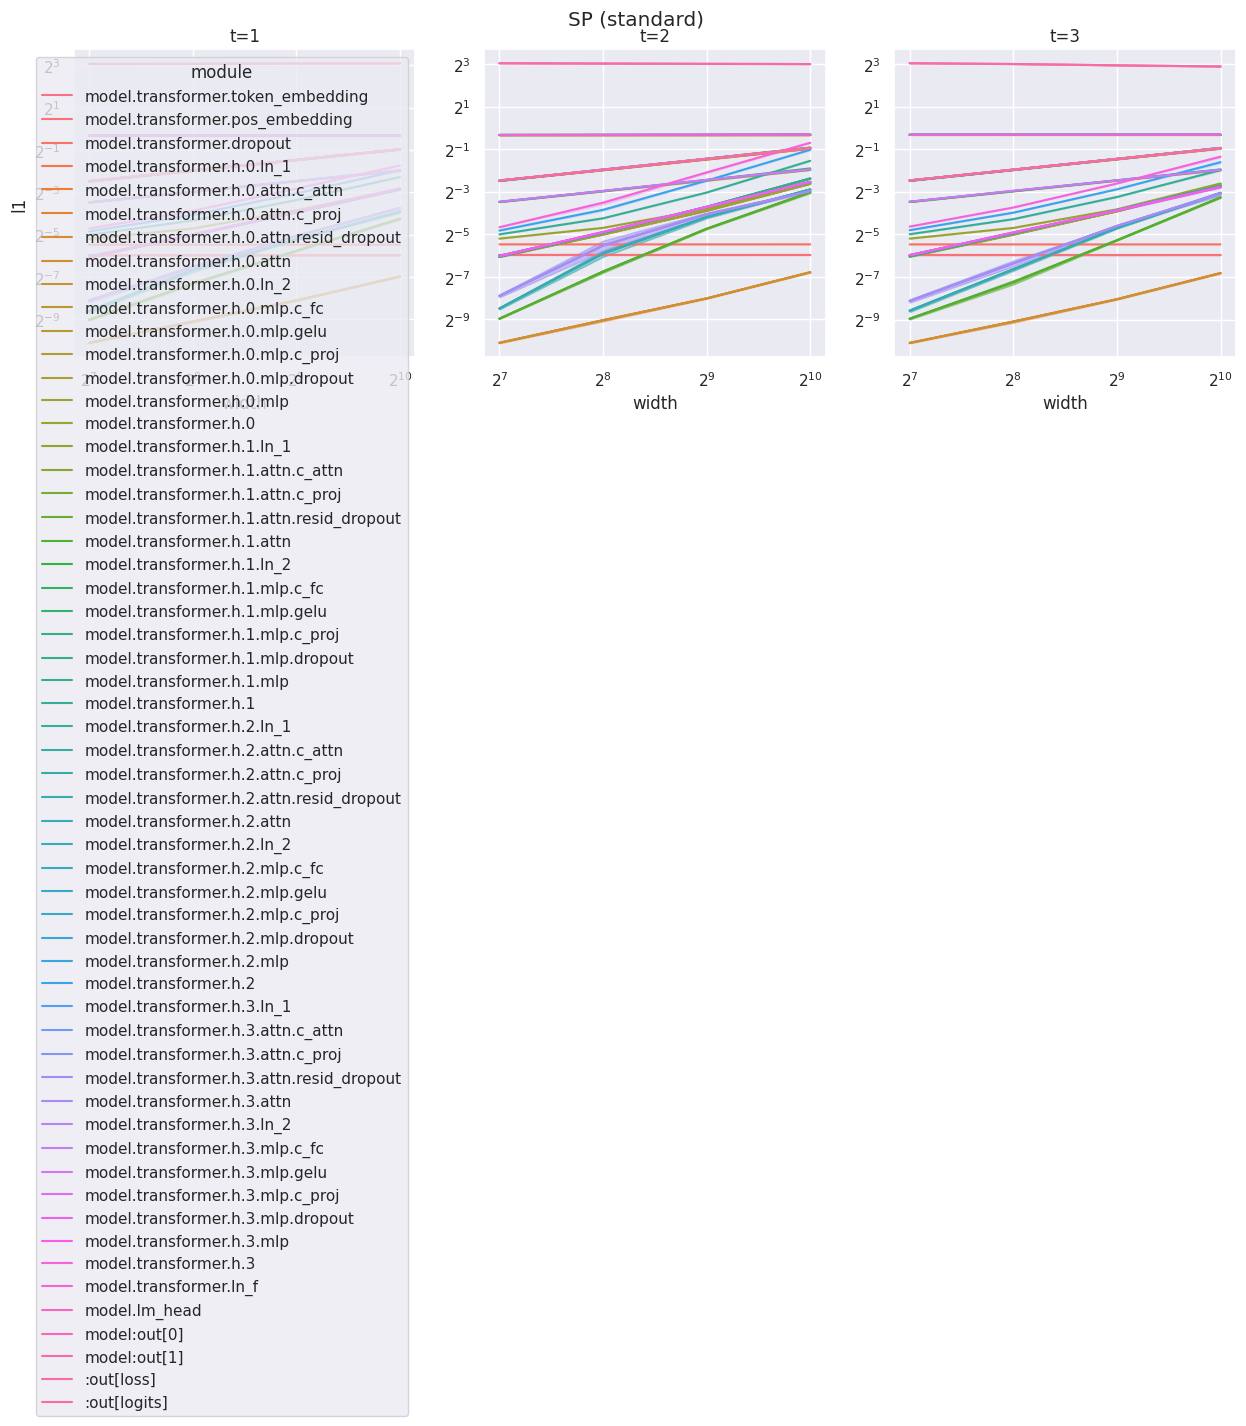

In [106]:
# Plot SP
plot_coord_data(df_sp, suptitle="SP (standard)")
plt.show()

This shows that activations grow with width under SP (standard parameterization), meaning the optimal LR shifts as you scale the LR tuned on a small model won't transfer to a large one.

/usr/local/lib/python3.12/dist-packages/mup/coord_check.py:489: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


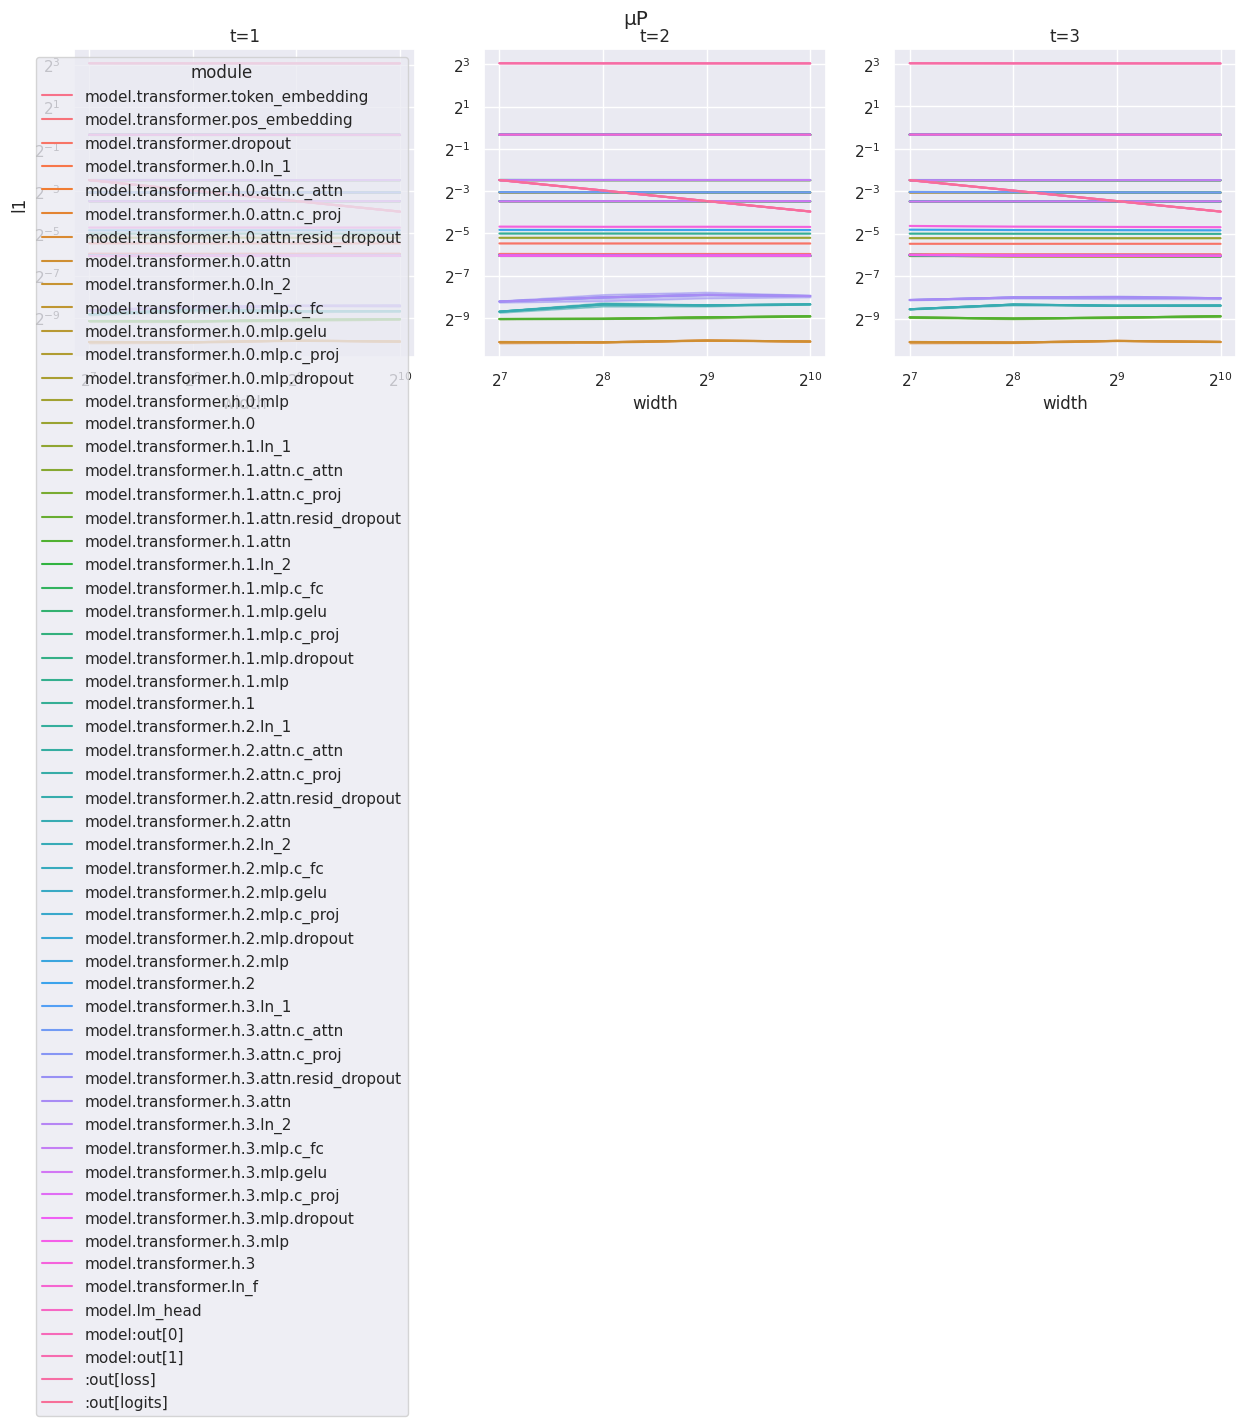

In [105]:
# Plot mup
plot_coord_data(df_mup, suptitle="µP")
plt.show()

Great! This shows us that wider models train with the same effective learning rate as narrow ones, so we've implemented μP correctly! Our plots mirror the ones shown in the `mup` [README](https://github.com/microsoft/mup#checking-correctness-of-parametrization).